In [1]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import textgrids
from pathlib import Path
import re

In [ ]:
def get_words(txt_dir, align_type="words"):
    tg_files = list(Path(txt_dir).rglob("*.TextGrid"))
    text = []

    for tg_path in tg_files:
        tg = textgrids.TextGrid(str(tg_path))
        tier = tg[align_type]

        for interval in tier:
            label = interval.text.strip().lower()
            if label in ["", "<unk>", "sp", "sil", "spn"]:
                continue
            #  remove numbers and decimals
            label = re.sub(r'\d+', '', label)
            text.append(label)
    
    if align_type == "phones":
        text = [re.sub(r'\d+', '', phn) for phn in text]

    return text

def get_clusters(partition_path):
    clusters = []
    current_cluster = []
    
    with open(partition_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            
            if len(parts) == 3:
                current_cluster.append(tuple(parts))
            
            elif len(parts) == 2 and current_cluster:
                clusters.append(current_cluster)
                current_cluster = [] 
                
        if current_cluster:
            clusters.append(current_cluster)

    return clusters

In [135]:
align_dir = Path("../data/alignments/LibriSpeech/dev-clean_feature_sliced")
partition_dir = Path("outputs/LibriSpeech/dev-clean_feature_sliced/wavlm_large/layer_21/gt/words/")

dataset = " ".join(partition_dir.parts[1:3])
info = " ".join(partition_dir.parts[3:])
print(f"Dataset: {dataset}")
print(f"Info: {info}")

align_type = "words"
words = get_words(align_dir, align_type)

Dataset: LibriSpeech dev-clean_feature_sliced
Info: wavlm_large layer_21 gt words


In [132]:
def get_data_label(stem):
    if "cosine" in stem:
        return f"{stem.split('_')[0].capitalize()} (t={stem.split('_')[1].split('t')[1]})"
    elif "edit" in stem and "lsh" in stem:
        return f"{stem.split('_')[0].capitalize()} (t={stem.split('_')[1].split('t')[1]}, LSH)"
    elif "edit" in stem:
        return f"{stem.split('_')[0].capitalize()} (t={stem.split('_')[1].split('t')[1]})"
    elif "kmeans" in stem:
        return f"KMeans"

def extract_threshold(path):
    label = get_data_label(path.stem)
    m = re.search(r"t=(\d*\.?\d+)", label)
    return float(m.group(1)) if m else float("inf")

# Distribution on a Log-log plot

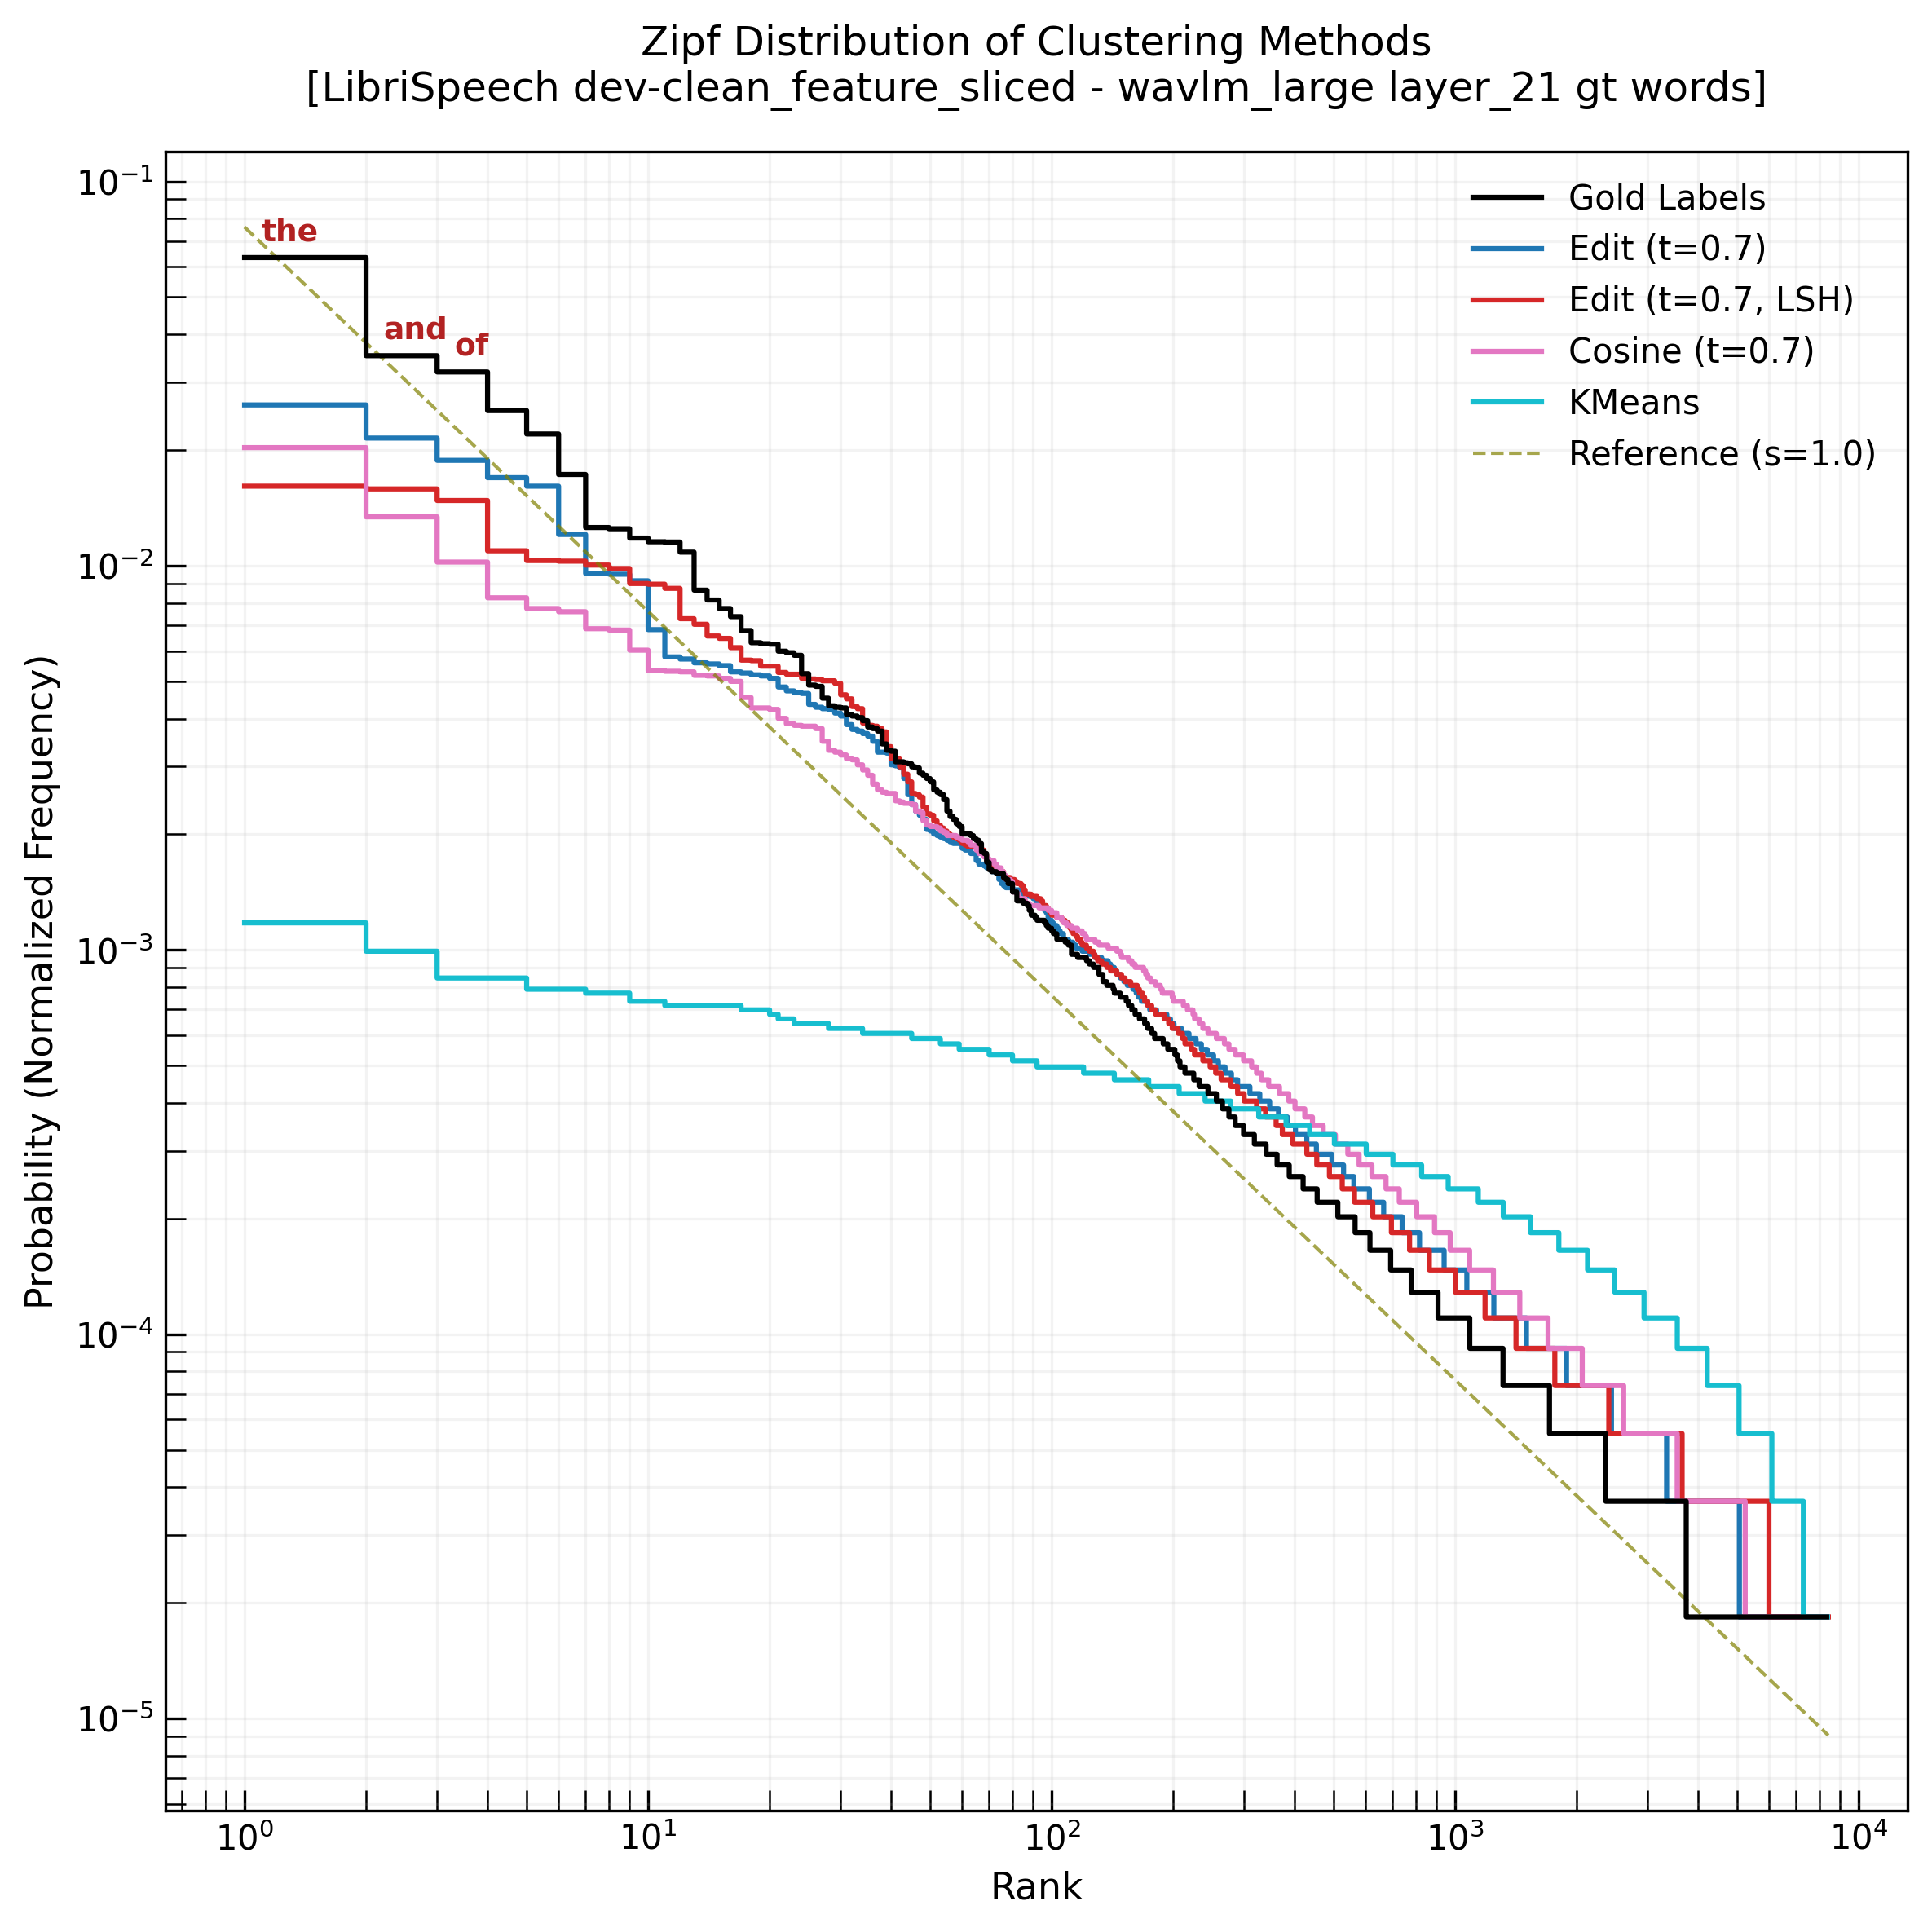

In [137]:
title = f"Zipf Distribution of Clustering Methods\n[{dataset} - {info}]"
paths = sorted(partition_dir.glob("*.txt"), key=extract_threshold)

fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
num_paths = len(paths)
color_map = plt.get_cmap('tab10', num_paths)

word_counts = Counter(words)
gold_unique_tokens, w_counts = zip(*word_counts.most_common())

w_counts_norm = np.array(w_counts) / sum(w_counts)
w_ranks = np.arange(1, len(w_counts_norm) + 1)

ax.loglog(w_ranks, w_counts_norm, linestyle='-', color='black', 
            linewidth=1.5, drawstyle='steps-post', label='Gold Labels', zorder=3)

for i in range(min(3, len(gold_unique_tokens))):
    ax.annotate(gold_unique_tokens[i], 
                (w_ranks[i], w_counts_norm[i]), 
                textcoords="offset points", 
                xytext=(5, 5), 
                ha='left', 
                fontsize=9, 
                fontweight='bold', 
                color='firebrick')

global_max_freq = 0
global_max_rank = 0

for i, path in enumerate(paths):
    try:
        data_label = get_data_label(path.stem)
    except NameError:
        data_label = "Empirical"
    
    clusters = get_clusters(path) 
    counts = sorted([len(c) for c in clusters], reverse=True)
    counts_norm = np.array(counts) / sum(counts)
    ranks = np.arange(1, len(counts) + 1)
    
    global_max_freq = max(global_max_freq, counts_norm[0])
    global_max_rank = max(global_max_rank, len(counts))

    ax.loglog(ranks, counts_norm, label=data_label, color=color_map(i), 
                linewidth=1.5, drawstyle='steps-post')
    
global_max_freq = max(global_max_freq, w_counts_norm[0])
global_max_rank = max(global_max_rank, len(w_counts_norm))

ref_ranks = np.logspace(0, np.log10(global_max_rank), 100)
ref_counts = (global_max_freq * 1.2) / (ref_ranks**1.0)

ax.loglog(ref_ranks, ref_counts, linestyle='--', color='olive', 
            alpha=0.7, linewidth=1, label='Reference (s=1.0)')

ax.set_title(title, fontsize=12, pad=15)
ax.set_xlabel('Rank', fontsize=11)
ax.set_ylabel('Probability (Normalized Frequency)', fontsize=11)

ax.grid(True, which="both", ls="-", alpha=0.15)
ax.tick_params(direction='in', which='both', length=6)
ax.legend(frameon=False, fontsize=10)

plt.tight_layout()
plt.show()


# Distribution on a Frequency Plot

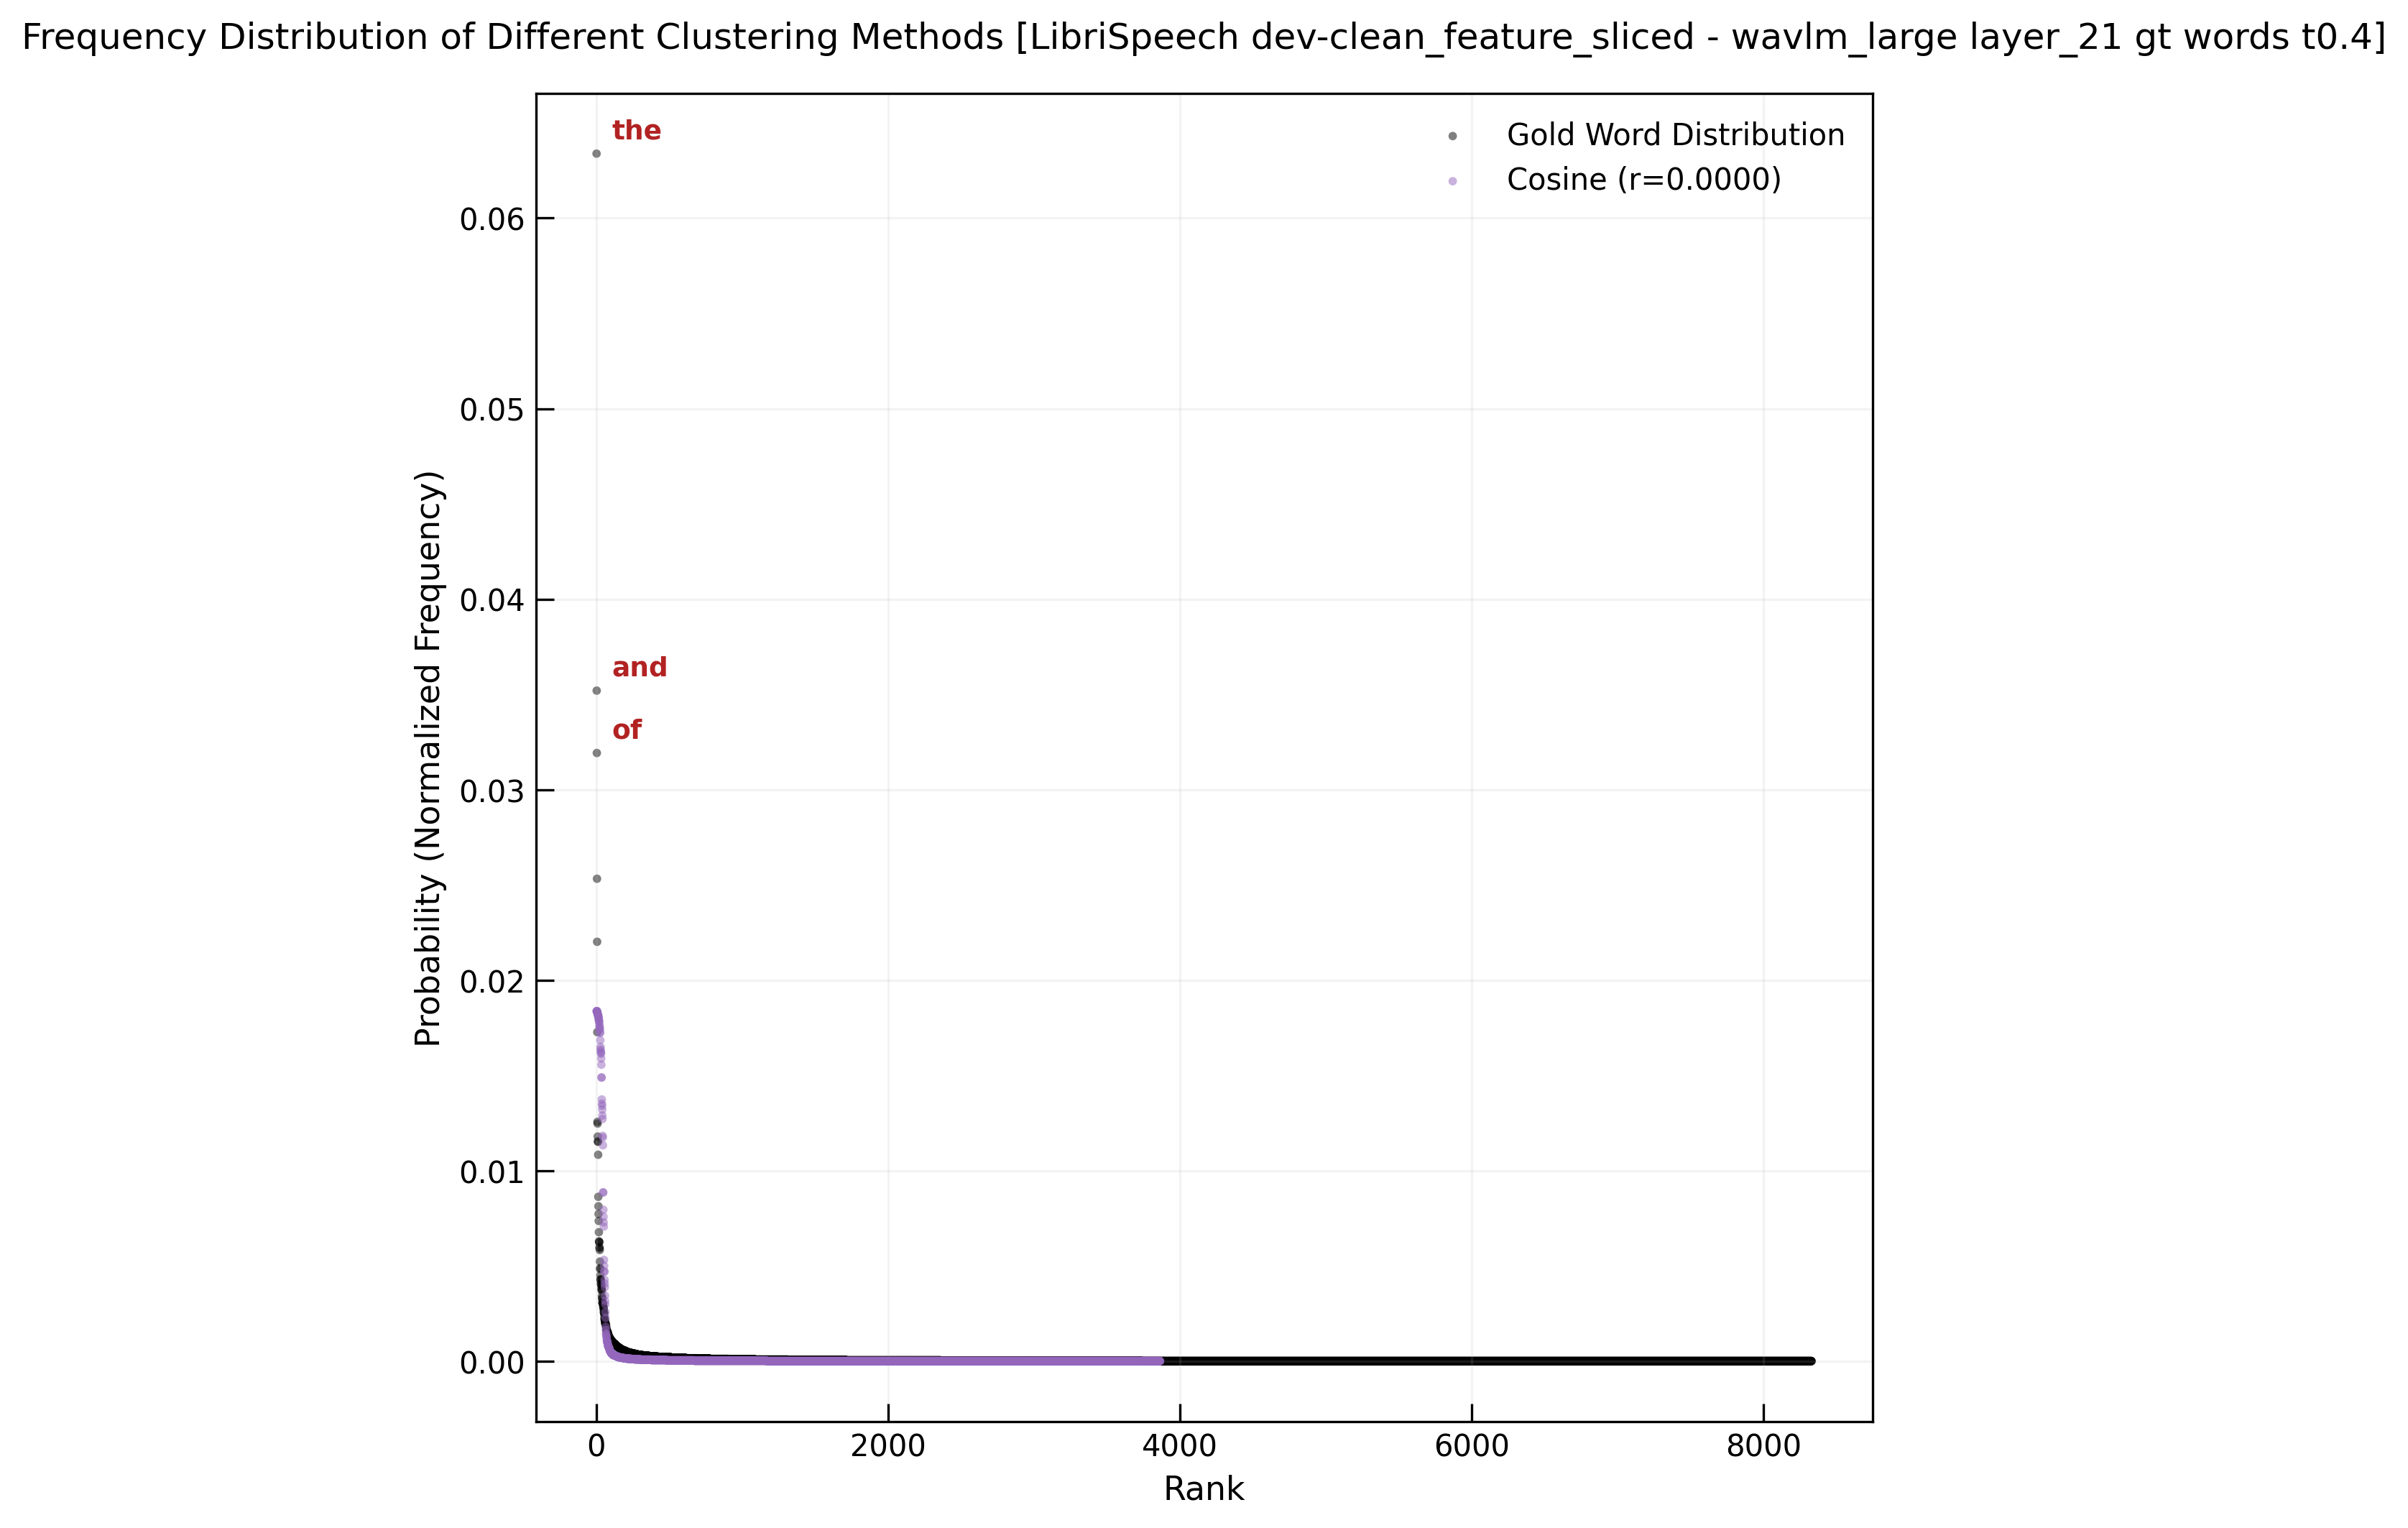

In [84]:
title = f"Frequency Distribution of Different Clustering Methods [{dataset} - {info}]"

fig, ax = plt.subplots(figsize=(8, 8), dpi=300)
num_paths = len(paths)
color_map = plt.get_cmap('tab10', num_paths)

word_counts = Counter(words)
_, w_counts = zip(*word_counts.most_common())
gold_word_freq = np.array(w_counts) / sum(w_counts)
w_ranks = np.arange(1, len(w_counts) + 1)

ax.scatter(w_ranks[:limit], gold_word_freq[:limit], color='black', s=8, 
    alpha=0.5, label='Gold Word Distribution', 
    edgecolors='none')

for i in range(min(3, len(gold_unique_tokens))):
    ax.annotate(gold_unique_tokens[i], 
                (w_ranks[i], gold_word_freq[i]), 
                textcoords="offset points", 
                xytext=(5, 5), 
                ha='left', 
                fontsize=9, 
                fontweight='bold', 
                color='firebrick')

global_max_freq = 0
global_max_rank = 0

path = Path("outputs/LibriSpeech/dev-clean_feature_sliced/wavlm_large/layer_21/gt/words/t0.4/cosine_t0.4_r0.0000_55.38.txt")

try:
    data_label = get_data_label(path.stem)
except NameError:
    data_label = "Empirical"

clusters = get_clusters(path) 
counts = sorted([len(c) for c in clusters], reverse=True)
counts_norm = np.array(counts) / sum(counts)
ranks = np.arange(1, len(counts) + 1)

global_max_freq = max(global_max_freq, counts_norm[0])
global_max_rank = max(global_max_rank, len(counts))

ax.scatter(ranks, counts_norm, color=color_map(i), s=8, 
        alpha=0.5, label=f'{data_label.capitalize()}', 
        edgecolors='none', zorder=5)

global_max_freq = max(global_max_freq, w_counts[0])
global_max_rank = max(global_max_rank, len(w_counts))

ax.set_title(title, fontsize=12, pad=15)
ax.set_xlabel('Rank', fontsize=11)
ax.set_ylabel('Probability (Normalized Frequency)', fontsize=11)

ax.grid(True, which="both", ls="-", alpha=0.15)
ax.tick_params(direction='in', which='both', length=6)
ax.legend(frameon=False, fontsize=10)